In [5]:
# Hafta 7


# Konu:
    ## Self-attention


# Bu hafta öğrenilecekler:
    ## Uzun bir metni eğitim verisine çevirmek
        ### karakter tokenizer
        ### train/val ayrımı
        ### Rastgele parçalardan batch
    ## Matris çarpımıyla ağırlıklı ortalama almak
        ### self-attention'ın arkasındaki hile
    ## query, key ve value
        ### bir token'ın hangi token'a ne kadar bakacağı nasıl hesaplanıyor
    ## Gelecekteki harfleri neden gizliyoruz: lower triangular maske 
        ### (torch.tril)
    ## attention sırayı bilmez: pozisyon embedding'i neden gerekli
    ## Skorları neden head_size'ın kareköküne bölüyoruz


# Bu haftanın görevleri:
    ## Görev 1: Veriyi hazırla ve tabanı kur. Tiny Shakespeare'i oku, karakter tokenizer'ını yaz (encode, decode), veriyi %90 train, %10 val diye ayır. Rastgele parçalardan batch çeken get_batch fonksiyonunu yaz. Hafta 2'deki bigram modelini nn.Module olarak kur, eğit, val loss'u kaydet. Bu senin karşılaştırma tabanın. (7:52 - 38:00)
    ## Görev 2: Geçmişin ortalamasını üç yoldan al: for döngüsüyle, lower triangular matrisle (torch.tril) çarparak, softmax'la. Üçünün aynı sonucu verdiğini torch.allclose ile göster. Matris çarpımının neden ağırlıklı ortalama olduğunu kendi cümlelerinle yaz. (42:13 - 58:26)
    ## Görev 3: Tek bir self-attention head yaz: query, key, value ve pozisyon embedding'i. Bir örnekte ağırlık matrisini (wei) yazdır, bir satırını oku: o token hangi token'lara ne kadar bakıyor. Skorları head_size'ın kareköküne neden böldüğümüzü sayıyla göster: bölmeden ve bölerek softmax çıktısını yan yana koy. (58:26 - 1:19:11)
    ## Görev 4: Head'i bigram modelinin içine koy ve eğit. Val loss'u 1. görevdeki bigram tabanıyla yan yana koy. Ne kadar düştü, neden düştü, kendi cümlelerinle yaz. Metin üretirken girdiyi neden son block_size harfe kırpmak zorunda olduğunu da yaz. (1:19:11 - 1:21:59)
    ## Görev 5: Ek, erken bitirenler için, ikisinden biri. (a) Eğitilmiş modelde bir cümlenin attention ağırlıklarını ısı haritası olarak çiz. Hangi harf hangisine bakıyor, ne gördüğünü yaz. (b) tril maskesini kaldırıp modeli yeniden eğit. Val loss ne oldu, ürettiği metin ne oldu? Sonucu gelecekteki harfleri görmekle açıkla.

In [24]:
# hazırlık
import torch

import torch.nn as nn
from torch.nn import functional as F

In [ ]:
# Görev 1: 
    ## Veriyi hazırla ve tabanı kur
    ## Tiny Shakespeare'i:
        ### oku
        ### karakter tokenizer'ını yaz (encode, decode) 
        ### veriyi %90 train, %10 val diye ayır
    ## Rastgele parçalardan batch çeken get_batch fonksiyonunu yaz
        ### Hafta 2'deki bigram modelini nn.Module olarak kur, eğit, val loss'u kaydet
            #### Bu senin karşılaştırma tabanın
    


# veriyi oku
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)


# tokenzer (encode, decode)
stoi = {ch: idx for idx,ch in enumerate(chars)}
itos = {idx: ch for idx,ch in enumerate(chars)}

def encode(text):
    encoding = []
    for char in text:
        encoding.append(stoi[char])
    
    return encoding

def decode(text):
    decoding = []
    for num in text:
        decoding.append(itos[num])
    
    return decoding

encode_text = encode("Merhaba Freya!")
decode_text = decode(encode_text)
print(f"Encode text: {encode_text}")
print(f"Decode text: {decode_text}")


# veriyi %90-10 split et
data = torch.tensor(encode(text), dtype=torch.long)
n = int(9*(len(data)/10))
X_tr  = data[:n]
X_val = data[n:]


# get_batch fonk. yaz  -  sample et metinlerden parçalar
torch.manual_seed(1337)
batch_size = 4
block_size = 8 

    ## trainig data sample etmek için bu
def get_batch(split):
    data = X_tr if split == 'train' else X_val

    ## data var elimizde... 
        ### ['arda', 'can', ...]
            #### a->0
            #### r->1
            #### d->2
            #### a->3
            #### c->4
            #### a->5
            #### n->6
        ### 0-6 arası sayı üretiyoz... 
            #### 1 geldi mesela ('r')
            #### (block_size=2 olsun)
            #### -> "o sayı" ve "o sayıdan block_size" kadarını aldık
                ##### 1:1+2 kadar aldık
                ##### rda aldık
        ### => batch size ne?
            #### "bu işlemi kaç kere yapıcaz? - kaç veri toplıcaz?"ın cevabı
        ### => e mesela 'd' aldık... 'd,a' oldu... "can"a geçer mi?
            #### (videoda açıklamamış ama tahminim + ai cevabı)
            #### evet geçiyo... şu an o "geçmeme" olayı yok
        ### => neden "- block_size"?
            #### " 'o sayı' + block_size" kadar alcaz ya...
            #### block_size, taşmamalı veri dışına
            
    idx = torch.randint(len(data) - block_size, (batch_size,))

    ## Mesela block_size=3 ve "Arda" yı düşün
        ### x = {A, r, d}
        ### y = {r, d, a}
    ## -> ondan, y hep +1 i alıyor x'ten
    x = torch.stack([data[i:i+block_size] for i in idx])
    y = torch.stack([data[i+1:i+block_size+1] for i in idx])

    return x,y


Xb, yb = get_batch('train')



for b in range(batch_size):
    for t in range(block_size):
        context = Xb[b, :t+1]
        target  = yb[b, t]

        ## => neden t+1??
            ### -> (!!) aslında, x = {A, r, d} değil (!!)
                #### x = {A, Ar, Ard}
                #### y = {r,  d,   a}
            ### => neden x = Xb[b, t] demedik? (Xb[b, :t+1] dedik?)
                ####  x = {A, Ar, Ard} gibi büyüyebilsin diye
                    ##### t in range(block_size) -> (0,1,2, ... ,8)
                #### sürekli büyüyor... büyüyebilsin diye yani

        #print(f"Input {context.tolist()} iken target {target}")

## özetle 2 şey yaptık:
    ### 1) örnek nasıl sample edilir?
        #### (tüm örnekleri birleşik gibi düşün)
        #### a. sayı sample et 
        #### b. + block_size ekle
    ### 2) sample edilen örnekler nasıl işlenir?
        #### x='A', x='Ar', x='Ard', ... gibi işlenir
        #### y='r', y= 'd', y=  'a', ... gibi olur




class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.embedding_lookup_table = nn.Embedding(vocab_size, vocab_size)

        ## mesela "Arda"ya bakalım
            ### x='A'  -  y='r'
        ## A harfi input 
        ## A harfi alındı (embedding e atıldı)
        ## lookup table a bakıldı:
                #### (vocab_size=26 kabul ederek yanıtladım)
            ### 26 harf - 26 embedding
            ### 26 input - 26 output
        ## => neden nn.Embedding(1,1) değil? 1 girip 1 çıkmıyor mu?
            ### burda, "layer" değil; "table"ı kodluyoruz
                #### nn.Embedding, otomatikman embedding üretiyor
            ### -> ondan (26,26)
                #### 26 "harf" var (input)
                #### 26 "üretilen embedding" var (output)
            ### -> yani layerlar ve boyutlar şu şekilde:
                #### input: (1,)
                    ##### 'a' alındı mesela
                #### embedding (1,26)
                    ##### (26,26)'lık tabloya bakıldı
                    ##### ordan 'a' harfinin embedding i bulundu ve (o embedding) output olarak verildi
                        ###### -> (!!!) bu da, direkt prediction oldu (!!!)
                            ####### her harf için olasılık tahmin edicez ya
                            ####### embedding table daki değer (embedding) direkt prediction oldu
                            #######'a' -> [0.12, -0.4, 2.1, ..., 0.5] 
                                ######## (Toplam 26 adet tahmin skoru / logit)
                #### output (26,)
                    ##### her harf için olasılık tahmini
                #### -> özetle: 1 -> 26

    def forward(self,idx,targets=None):
        """
        # Ana Fikir Bu:
        logits = self.embedding_lookup_table(idx) # input  ---- embedding ---- > output
        loss = F.cross_entropy(logits, targets)
        """

        logits = self.embedding_lookup_table(idx)

        if targets == None:
            loss = None
        else:
            ## B: batch (örnek) sayısı
            ## T: block_size
                ### wavenet te kaç grup olduğu idi
            ## C: channel
                ### her bir harf kaç boyutlu?
                ### output:vocab_size yaptık diye burda vocab_size kadar direkt
                    #### ara layer olsa, n_emb kadar olurdu boyutu
            B,T,C = logits.shape

            logits = logits.view(B*T,C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits,targets)
        
        return logits,loss
    

    def generate(self,idx,max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self(idx)

            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx



bigram_model = BigramLanguageModel(vocab_size)
logits, loss = bigram_model(Xb,yb)
print(f"Initial loss: {loss}")
print(decode(bigram_model.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))



optimizer = torch.optim.AdamW(bigram_model.parameters(), lr=1e-3)

batch_size = 32
for steps in range(10000):
    xb,yb = get_batch('train')
    logits,loss=bigram_model(xb,yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(f"Bigram - train loss: {loss.item()}")

Encode text: [25, 43, 56, 46, 39, 40, 39, 1, 18, 56, 43, 63, 39, 2]
Decode text: ['M', 'e', 'r', 'h', 'a', 'b', 'a', ' ', 'F', 'r', 'e', 'y', 'a', '!']
Initial loss: 4.460883140563965
['\n', 'l', 'f', 'J', 'e', 'u', 'k', 'R', 'u', 'a', 'R', 'J', 'K', 'X', 'A', 'Y', 't', 'X', 'z', 'f', 'J', ':', 'H', 'E', 'P', 'i', 'u', '-', '-', 's', 'D', 'i', 'o', 'i', ';', 'I', 'L', 'C', 'o', '3', 'p', 'H', 'N', 'T', 'm', 'D', 'w', 'J', 's', 'f', 'h', 'e', 'K', 'R', 'x', 'Z', 'C', 'F', 's', '\n', 'l', 'Z', 'J', ' ', 'X', 'Q', 'c', '?', ':', 's', ':', 'H', 'E', 'z', 'E', 'n', 'X', 'a', 'l', 'E', 'P', 'k', 'l', 'c', 'P', 'U', ' ', 'c', 'L', "'", 'D', 'p', 'd', 'L', 'C', 'a', 'f', 'B', 'h', 'e', 'H']
Bigram - train loss: 2.5691940784454346


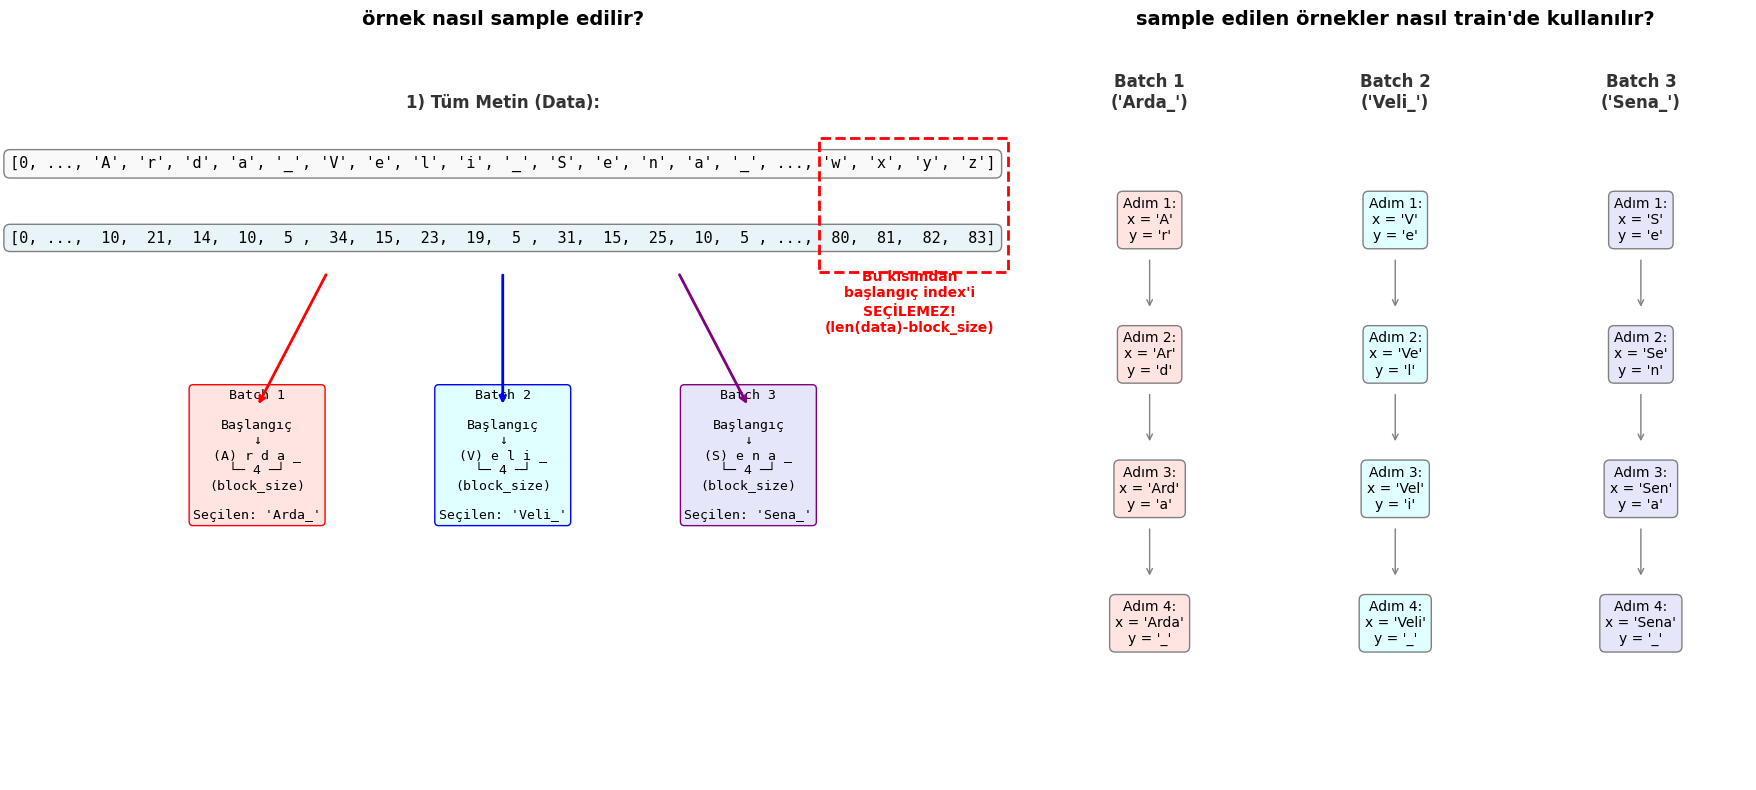

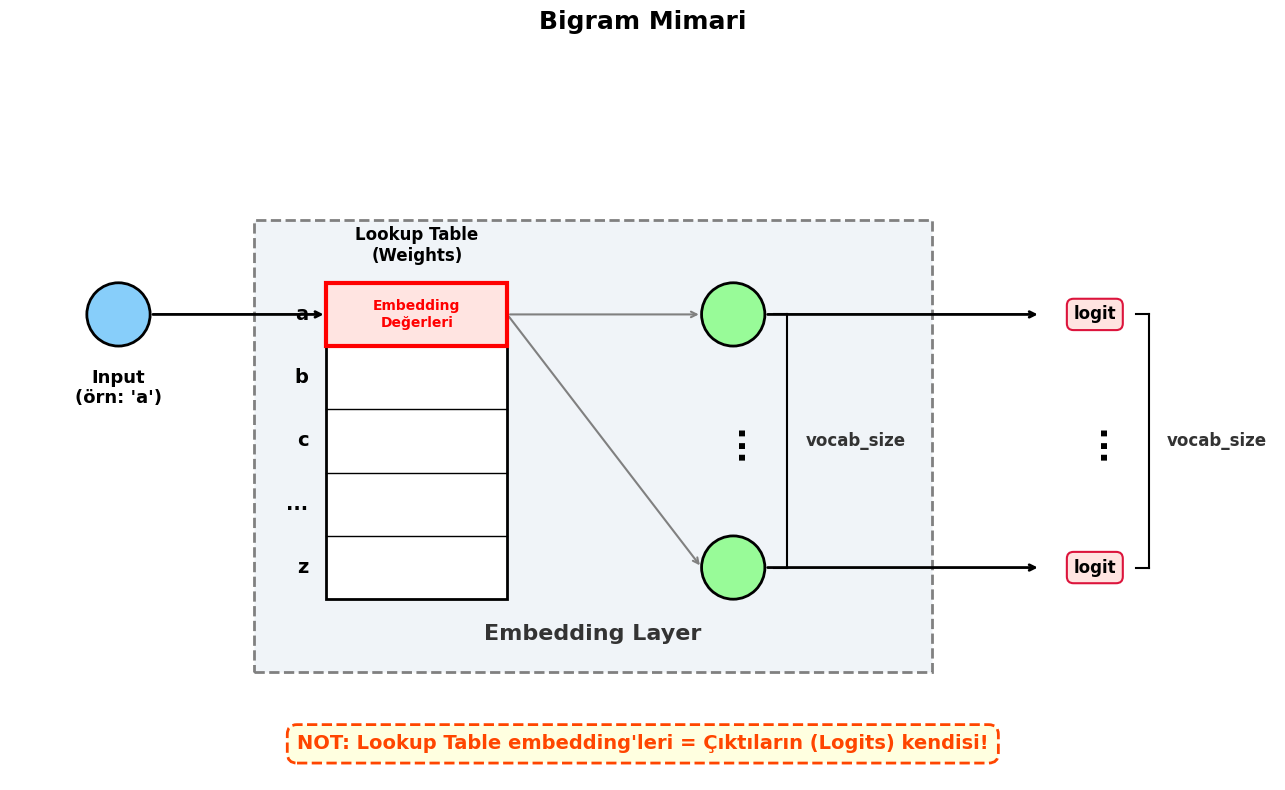

In [71]:
# görselleştirme
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# ================= SOL PANEL =================
ax1.set_title("örnek nasıl sample edilir?", fontsize=14, fontweight='bold')
ax1.axis('off')

# Temsili veri seti (Harfler)
ax1.text(0.5, 0.90, "1) Tüm Metin (Data):", fontsize=12, ha='center', fontweight='bold', color='#333333')
metin = "[0, ..., 'A', 'r', 'd', 'a', '_', 'V', 'e', 'l', 'i', '_', 'S', 'e', 'n', 'a', '_', ..., 'w', 'x', 'y', 'z']"
ax1.text(0.5, 0.82, metin, fontsize=11, ha='center', fontfamily='monospace', 
         bbox=dict(boxstyle="round,pad=0.4", fc="#f9f9f9", ec="gray"))

# Temsili veri seti (Sayılar / Token ID'leri)
sayilar = "[0, ...,  10,  21,  14,  10,  5 ,  34,  15,  23,  19,  5 ,  31,  15,  25,  10,  5 , ...,  80,  81,  82,  83]"
ax1.text(0.5, 0.72, sayilar, fontsize=11, ha='center', fontfamily='monospace', 
         bbox=dict(boxstyle="round,pad=0.4", fc="#e8f4f8", ec="gray"))

# Genişlik 0.27 yapıldı (y ve z'yi de kapsaması için) ve yazı ortalandı
rect = patches.Rectangle((0.95, 0.68), 0.27, 0.18, linewidth=2, edgecolor='red', facecolor='none', linestyle='--', zorder=3, clip_on=False)
ax1.add_patch(rect)
ax1.text(1.08, 0.60, "Bu kısımdan\nbaşlangıç index'i\nSEÇİLEMEZ!\n(len(data)-block_size)", 
         fontsize=10, ha='center', color='red', fontweight='bold')


# Sample blokları (Kutular iyice daraltıldı, araları açıldı, font küçültüldü)
b1_str = "Batch 1\n\nBaşlangıç\n↓\n(A) r d a _\n└─ 4 ─┘\n(block_size)\n\nSeçilen: 'Arda_'"
ax1.text(0.15, 0.35, b1_str, fontsize=9.5, ha='center', fontfamily='monospace', bbox=dict(boxstyle="round,pad=0.3", fc="#ffe4e1", ec="red"))

b2_str = "Batch 2\n\nBaşlangıç\n↓\n(V) e l i _\n└─ 4 ─┘\n(block_size)\n\nSeçilen: 'Veli_'"
ax1.text(0.50, 0.35, b2_str, fontsize=9.5, ha='center', fontfamily='monospace', bbox=dict(boxstyle="round,pad=0.3", fc="#e0ffff", ec="blue"))

b3_str = "Batch 3\n\nBaşlangıç\n↓\n(S) e n a _\n└─ 4 ─┘\n(block_size)\n\nSeçilen: 'Sena_'"
ax1.text(0.85, 0.35, b3_str, fontsize=9.5, ha='center', fontfamily='monospace', bbox=dict(boxstyle="round,pad=0.3", fc="#e6e6fa", ec="purple"))

# Oklar (Data'dan kutulara) - Yeni pozisyonlara göre hizalandı
ax1.annotate('', xy=(0.15, 0.50), xytext=(0.25, 0.68), arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax1.annotate('', xy=(0.50, 0.50), xytext=(0.50, 0.68), arrowprops=dict(arrowstyle="->", color="blue", lw=2))
ax1.annotate('', xy=(0.85, 0.50), xytext=(0.75, 0.68), arrowprops=dict(arrowstyle="->", color="purple", lw=2))


# ================= SAĞ PANEL (Dokunulmadı) =================
ax2.set_title("sample edilen örnekler nasıl train'de kullanılır?", fontsize=14, fontweight='bold')
ax2.axis('off')

batches = ["Arda_", "Veli_", "Sena_"]
renkler = ["#ffe4e1", "#e0ffff", "#e6e6fa"]
x_pos = [0.15, 0.5, 0.85]

for b_idx, word in enumerate(batches):
    ax2.text(x_pos[b_idx], 0.9, f"Batch {b_idx+1}\n('{word}')", fontsize=12, fontweight='bold', ha='center', color='#333333')
    
    y = 0.75
    for i in range(len(word)-1):
        x_str = word[:i+1]
        y_str = word[i+1]
        
        kutu_metni = f"Adım {i+1}:\nx = '{x_str}'\ny = '{y_str}'"
        ax2.text(x_pos[b_idx], y, kutu_metni, fontsize=10, ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.4", fc=renkler[b_idx], ec="gray"))
        
        if i < len(word)-2:
            ax2.annotate('', xy=(x_pos[b_idx], y-0.12), xytext=(x_pos[b_idx], y-0.05),
                         arrowprops=dict(arrowstyle="->", color="gray"))
            
        y -= 0.18

plt.tight_layout()
plt.show()


# Bigram Mimari Görselleştirmesi
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_title("Bigram Mimari", fontsize=18, fontweight='bold', pad=20)
ax.axis('off')

# Oranların bozulmaması için (Tam daireler ve düzgün kareler)
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.set_aspect('equal')

# Gruplamalar için süslü parantez (brace) çizen yardımcı fonksiyon
def draw_brace(ax, x, y_bottom, y_top, text):
    ax.plot([x, x], [y_bottom, y_top], color='black', lw=1.5)
    ax.plot([x, x-0.15], [y_top, y_top], color='black', lw=1.5)
    ax.plot([x, x-0.15], [y_bottom, y_bottom], color='black', lw=1.5)
    ax.text(x + 0.2, (y_bottom + y_top) / 2, text, va='center', ha='left', fontsize=12, fontweight='bold', color='#333333')

r = 0.35 # Nöron yarıçapı

# ================= 1. INPUT NÖRONU =================
input_x, input_y = 1.2, 5.15
ax.add_patch(patches.Circle((input_x, input_y), r, color='#87CEFA', ec='black', lw=2, zorder=3))
ax.text(input_x, input_y - 0.6, "Input\n(örn: 'a')", ha='center', va='top', fontsize=13, fontweight='bold')

# ================= 2. EMBEDDING LAYER (KUTU VE İÇİNDEKİLER) =================
# Embedding katmanını saran estetik kesikli dış kutu
emb_box = patches.Rectangle((2.7, 1.2), 7.5, 5.0, color='#f0f4f8', ec='gray', lw=2, ls='--', zorder=1)
ax.add_patch(emb_box)
ax.text(6.45, 1.5, "Embedding Layer", ha='center', va='bottom', fontsize=16, fontweight='bold', color='#333333')

# A. LOOKUP TABLE (Matrisin Kendisi)
table_x = 3.5
table_y = 2.0
table_w = 2.0
table_h = 3.5
# Dış çerçeve
ax.add_patch(patches.Rectangle((table_x, table_y), table_w, table_h, ec='black', fc='white', lw=2, zorder=2))
# Matrisin iç satır çizgileri
for i in range(1, 5):
    ax.plot([table_x, table_x + table_w], [table_y + i*0.7, table_y + i*0.7], color='black', lw=1, zorder=2)

# Satır isimleri (a, b, c...)
labels = ['z', '...', 'c', 'b', 'a']
for i, lbl in enumerate(labels):
    ax.text(table_x - 0.2, table_y + i*0.7 + 0.35, lbl, ha='right', va='center', fontsize=14, fontweight='bold')
ax.text(table_x + table_w/2, table_y + table_h + 0.2, "Lookup Table\n(Weights)", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Input'un seçtiği 'a' satırını Kırmızı Kutucuk içine alma (Vurgulama)
ax.add_patch(patches.Rectangle((table_x, 4.8), table_w, 0.7, ec='red', fc='#ffe4e1', lw=3, zorder=3))
ax.text(table_x + table_w/2, 5.15, "Embedding\nDeğerleri", ha='center', va='center', fontsize=10, color='red', fontweight='bold', zorder=4)

# Input'tan Lookup Table'ın 'a' satırına giden ok
ax.annotate('', xy=(table_x, 5.15), xytext=(input_x + r, 5.15),
            arrowprops=dict(arrowstyle="->", color="black", lw=2), zorder=2)

# B. EMBEDDING NÖRONLARI
emb_x = 8.0
# ÇÖZÜM: Ortadaki nöronu kaldırdık. Sadece en üst ve en alt nöronları çiziyoruz.
emb_y_list = [5.15, 2.35] 

for y in emb_y_list:
    ax.add_patch(patches.Circle((emb_x, y), r, color='#98FB98', ec='black', lw=2, zorder=3))
    # Kırmızı kutuya alınan satırdan bu nöronlara dağılan oklar
    ax.annotate('', xy=(emb_x - r, y), xytext=(table_x + table_w, 5.15),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5), zorder=2)

# Nöronlar arası "..." tam ortaya (3.75) alındı. Böylece hiçbir ok içinden geçmeyecek.
ax.text(emb_x, 3.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')
draw_brace(ax, emb_x + 0.6, 2.35, 5.15, "vocab_size")


# ================= 3. ÇIKIŞ (LOGITS) =================
logit_x = 12.0
for y in emb_y_list:
    # Nöronlardan -> Dışarı (Logit'e) çıkan oklar
    ax.annotate('', xy=(logit_x - 0.6, y), xytext=(emb_x + r, y),
                arrowprops=dict(arrowstyle="->", color="black", lw=2), zorder=2)
    
    # Logit kutucukları
    ax.text(logit_x, y, "logit", ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", fc="#ffe4e1", ec="#dc143c", lw=1.5))

# Logitler arası "..." tam ortaya (3.75) alındı.
ax.text(logit_x, 3.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')
draw_brace(ax, logit_x + 0.6, 2.35, 5.15, "vocab_size")


# ================= 4. ALT BİLGİ NOTU =================
ax.text(7.0, 0.4, "NOT: Lookup Table embedding'leri = Çıktıların (Logits) kendisi!", 
        ha='center', va='center', fontsize=14, fontweight='bold', color='#ff4500',
        bbox=dict(boxstyle="round,pad=0.5", fc="#ffffE0", ec="#ff4500", lw=2, ls='--'))

plt.tight_layout()
plt.show()

In [54]:
# Görev 2: 
    ## Geçmişin ortalamasını üç yoldan al: 
        ### for döngüsüyle
        ### lower triangular matrisle (torch.tril) çarparak
        ### softmax'la
    ## Üçünün aynı sonucu verdiğini torch.allclose ile göster
    ## Matris çarpımının neden ağırlıklı ortalama olduğunu kendi cümlelerinle yaz

B,T,C = 4,8,2
x = torch.randn(B,T,C)


# for döngüsü
xbow_for = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        ## sadece t değişecek
            ### B: örnekler
                #### hafıza, farklı örnekler arası olmayacak
                #### -> Aynı örnekteki, "o eleman -> o elemandan önceki elemanlar" diye olcak
            ### T: time
                #### mesela, "Arda"
                #### "A", "Ar", "Ard", "Arda" diye gider ya
                #### "Ard" iken, bu ("Ard") eskilere ("A" ve "Ar"ye) erişebilir
        xprev     = x[b,:t+1]
        xbow_for[b,t] = torch.mean(xprev,0)

# lower triangle
    ## torch.trill( torch.ones(3,3) )
        ### 1 0 0
        ### 1 1 0
        ### 1 1 1
    
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow_trill = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
print(torch.allclose(xbow_for, xbow_trill))

# softmax
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow_softmax = wei @ x
print(torch.allclose(xbow_trill, xbow_softmax))

True
True


### Matris çarpımı neden ağırlıklı ortalama?

Çünkü, bütün sonuçları "standartize (scale)" etmemiz lazım ki beraber kullanabilelim... bunun için, 0-1 arasına alıyoruz sonuçları ve ağırlığı büyük olanlar 1'e yakın oluyor

In [ ]:
# Görev 3: 
    ## Tek bir self-attention head yaz
        ### query, key, value ve pozisyon embedding'i
    ## Bir örnekte ağırlık matrisini (wei) yazdır, bir satırını oku
        ### o token hangi token'lara ne kadar bakıyor. 
    ### Skorları head_size'ın kareköküne neden böldüğümüzü sayıyla göster
        ### bölmeden ve bölerek softmax çıktısını yan yana koy. 


B,T,C = 4,8,2
x = torch.randn(B,T,C)
pos_emb = torch.randn(T, C) 
x = x + pos_emb  

head_size = 16

## temel fikir:
    ### w = q @ k.T yap
    ### w @ v hesapla
## => k ve q ne?
        ### "q @ k.T" attention yapmadan önce bunları (q ve k'yi) hesaplardık ya...
    ### q = x @ W_q
    ### k = x @ W_k
    ### => aynı koddan (ikisinde de nn.Linear(...) var) farklı sonuç nasıl gelir?
        #### -> (!!!) W_k ve W_q'lar farklı... o sayede
## => neden C?
    ### B: farklı örnekler
    ### T: her bir örnekteki elemanlar/tokenlar (harfler,kelimeler vs.)
    ### attention ne yapardı?
        #### tokenları birbirleri ile kıyaslar (T)
        #### her bi örnek içinde yapar bunu (B)
## => head_size ne?
    ### C'nin yerine geliyor
        #### C, n_embd gibiydi ya...
            ##### char'ların kaç boyutlu embedding'i olduğu gibi
        #### -> "transformer'ın işleyebileceği cins"e çeviriyor
            ##### embedding'i embedding'e çevirmek için
    ### => (attention-)head ne?
        #### -> her attention-head tüm metne bakar; ama başka bir açıdan bakar
            ##### bir attention head, "duygu uyumu"na bakar
            ##### bir attention head, "grammer uyumuna" bakar vs.
        #### -> C=64 ise mesela... head_size=16 ise mesela: "4 tane attention-head"in var demektir



# scale etmeden
key = nn.Linear(C, head_size, bias=False)   
query = nn.Linear(C, head_size, bias=False) 
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # k = x @ W_k
q = query(x) # q = x @ W_q
v = value(x) # v = x @ W_v

wei = q @ k.transpose(-2,-1)  # (B,T,16) @ (B,16,T) --> (B,T,T)


## bu kısım olmasa "self-attention" olurdu  -  bu var diye "masked attention" oldu
tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
out = wei @ v





# scale ederek
wei2 = ( q @ k.transpose(-2,-1) ) * (head_size ** -0.5) # sadece bunu ekledik, bu oldu

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei2 = wei2.masked_fill(tril == 0, float('-inf'))
wei2 = F.softmax(wei2, dim=-1)


# Bilimsel gösterimi kapatmak için
torch.set_printoptions(sci_mode=False, precision=4)

print(f"Scale olmayan output:\n{wei[0,4]}\n")
print(f"Scaled output:\n{wei2[0,4]}") 

Scale olmayan output:
tensor([0.1197, 0.4011, 0.3527, 0.0795, 0.0470, 0.0000, 0.0000, 0.0000],
       grad_fn=<SelectBackward0>)

Scaled output:
tensor([0.1867, 0.2525, 0.2446, 0.1685, 0.1477, 0.0000, 0.0000, 0.0000],
       grad_fn=<SelectBackward0>)


-> Scale olmayanda değerler daha dengesiz dağılır... örneğin:
- Scale olmayanda:
    * 0.40 ve 0.35 var... çoğunu kapmışlar

- Scaled olanda:
    * tüm değerler 0.14-0.25 arasına yayılmış

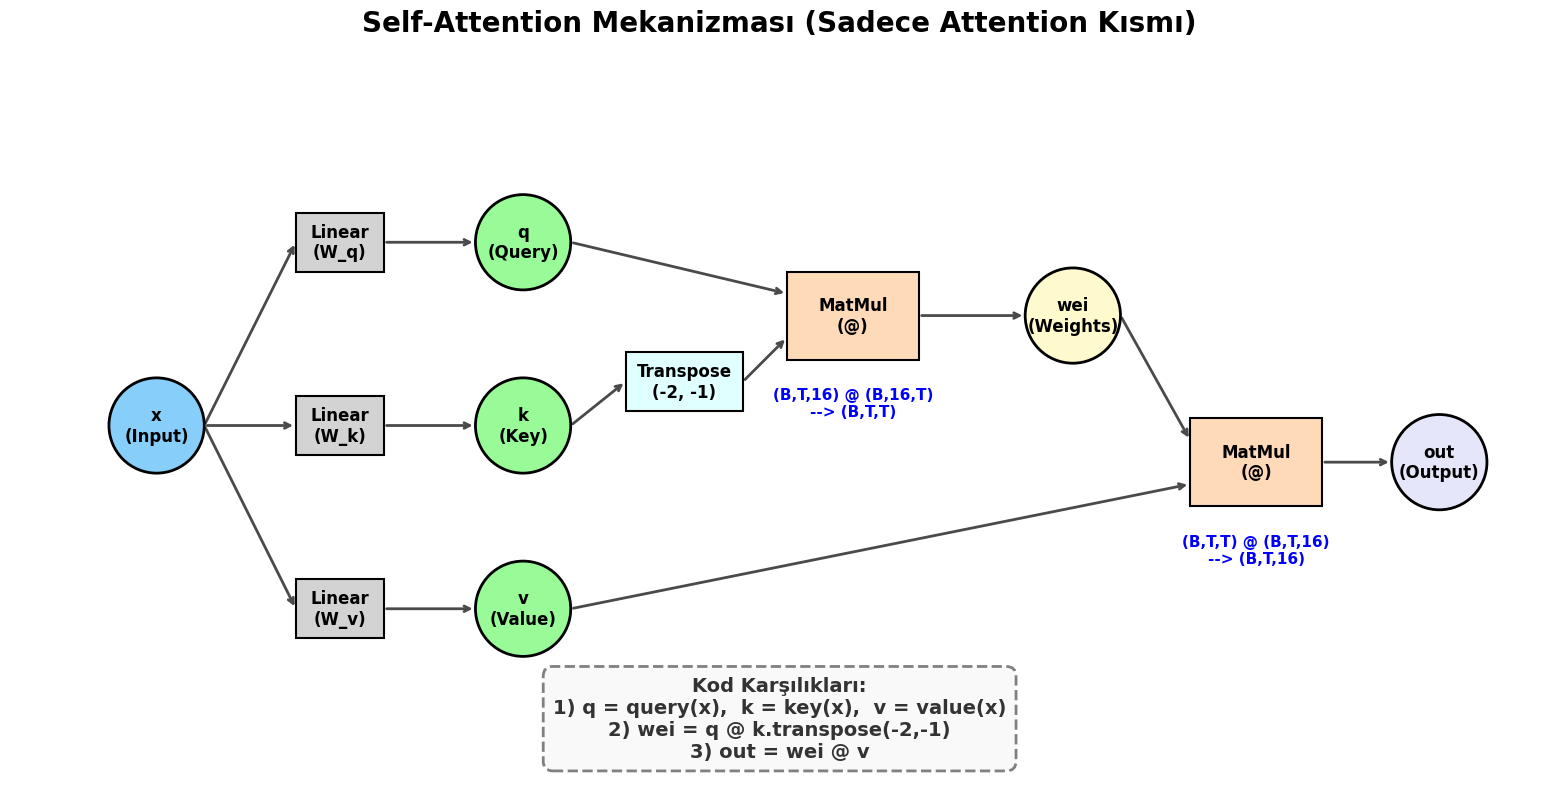

In [72]:
# görselleştirme

# Self-Attention Mekanizması Görselleştirmesi
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_title("Self-Attention Mekanizması (Sadece Attention Kısmı)", fontsize=20, fontweight='bold', pad=20)
ax.axis('off')

# Çizim alanının oranları
ax.set_xlim(0, 21)
ax.set_ylim(0, 10)
ax.set_aspect('equal')

# Ortak ayarlar
r = 0.65
arr = dict(arrowstyle="->", color="#4a4a4a", lw=2)

def draw_node(ax, x, y, text, color):
    ax.add_patch(patches.Circle((x, y), r, color=color, ec='black', lw=2, zorder=3))
    ax.text(x, y, text, ha='center', va='center', fontsize=12, fontweight='bold', zorder=4)

def draw_box(ax, x, y, w, h, text, color):
    ax.add_patch(patches.Rectangle((x - w/2, y - h/2), w, h, ec='black', fc=color, lw=1.5, zorder=3))
    ax.text(x, y, text, ha='center', va='center', fontsize=12, fontweight='bold', zorder=4)

# ================= 1. DÜĞÜMLER VE KUTULAR =================

# Input
input_x, input_y = 2.0, 5.0
draw_node(ax, input_x, input_y, "x\n(Input)", '#87CEFA')

# Linear Katmanları (Ağırlıklar)
lin_x = 4.5
draw_box(ax, lin_x, 7.5, 1.2, 0.8, "Linear\n(W_q)", '#D3D3D3')
draw_box(ax, lin_x, 5.0, 1.2, 0.8, "Linear\n(W_k)", '#D3D3D3')
draw_box(ax, lin_x, 2.5, 1.2, 0.8, "Linear\n(W_v)", '#D3D3D3')

# Q, K, V Nöronları
qkv_x = 7.0
q_y, k_y, v_y = 7.5, 5.0, 2.5
draw_node(ax, qkv_x, q_y, "q\n(Query)", '#98FB98')
draw_node(ax, qkv_x, k_y, "k\n(Key)", '#98FB98')
draw_node(ax, qkv_x, v_y, "v\n(Value)", '#98FB98')

# Transpose Kutusu
trans_x, trans_y = 9.2, 5.6
draw_box(ax, trans_x, trans_y, 1.6, 0.8, "Transpose\n(-2, -1)", '#E0FFFF')

# Birinci MatMul (q @ k.T)
mm1_x, mm1_y = 11.5, 6.5
draw_box(ax, mm1_x, mm1_y, 1.8, 1.2, "MatMul\n(@)", '#FFDAB9')
ax.text(mm1_x, mm1_y - 1.2, "(B,T,16) @ (B,16,T)\n--> (B,T,T)", ha='center', va='center', fontsize=11, color='blue', fontweight='bold')

# wei Nöronu
wei_x, wei_y = 14.5, 6.5
draw_node(ax, wei_x, wei_y, "wei\n(Weights)", '#FFFACD')

# İkinci MatMul (wei @ v)
mm2_x, mm2_y = 17.0, 4.5
draw_box(ax, mm2_x, mm2_y, 1.8, 1.2, "MatMul\n(@)", '#FFDAB9')
ax.text(mm2_x, mm2_y - 1.2, "(B,T,T) @ (B,T,16)\n--> (B,T,16)", ha='center', va='center', fontsize=11, color='blue', fontweight='bold')

# Output Nöronu
out_x, out_y = 19.5, 4.5
draw_node(ax, out_x, out_y, "out\n(Output)", '#E6E6FA')


# ================= 2. OKLAR (BAĞLANTILAR) =================

# Input -> Linears
ax.annotate('', xy=(lin_x - 0.6, 7.5), xytext=(input_x + r, input_y), arrowprops=arr, zorder=2)
ax.annotate('', xy=(lin_x - 0.6, 5.0), xytext=(input_x + r, input_y), arrowprops=arr, zorder=2)
ax.annotate('', xy=(lin_x - 0.6, 2.5), xytext=(input_x + r, input_y), arrowprops=arr, zorder=2)

# Linears -> Q, K, V
ax.annotate('', xy=(qkv_x - r, q_y), xytext=(lin_x + 0.6, 7.5), arrowprops=arr, zorder=2)
ax.annotate('', xy=(qkv_x - r, k_y), xytext=(lin_x + 0.6, 5.0), arrowprops=arr, zorder=2)
ax.annotate('', xy=(qkv_x - r, v_y), xytext=(lin_x + 0.6, 2.5), arrowprops=arr, zorder=2)

# K -> Transpose -> MatMul1
ax.annotate('', xy=(trans_x - 0.8, trans_y), xytext=(qkv_x + r, k_y), arrowprops=arr, zorder=2)
ax.annotate('', xy=(mm1_x - 0.9, 6.2), xytext=(trans_x + 0.8, trans_y), arrowprops=arr, zorder=2)

# Q -> MatMul1
ax.annotate('', xy=(mm1_x - 0.9, 6.8), xytext=(qkv_x + r, q_y), arrowprops=arr, zorder=2)

# MatMul1 -> wei
ax.annotate('', xy=(wei_x - r, wei_y), xytext=(mm1_x + 0.9, mm1_y), arrowprops=arr, zorder=2)

# wei -> MatMul2
ax.annotate('', xy=(mm2_x - 0.9, 4.8), xytext=(wei_x + r, wei_y), arrowprops=arr, zorder=2)

# V -> MatMul2
ax.annotate('', xy=(mm2_x - 0.9, 4.2), xytext=(qkv_x + r, v_y), arrowprops=arr, zorder=2)

# MatMul2 -> out
ax.annotate('', xy=(out_x - r, out_y), xytext=(mm2_x + 0.9, mm2_y), arrowprops=arr, zorder=2)


# ================= 3. KOD BİLGİSİ (ALT KISIM) =================
kod_metni = (
    "Kod Karşılıkları:\n"
    "1) q = query(x),  k = key(x),  v = value(x)\n"
    "2) wei = q @ k.transpose(-2,-1)\n"
    "3) out = wei @ v"
)
ax.text(10.5, 1.0, kod_metni, fontsize=14, fontweight='bold', color='#333333',
        bbox=dict(boxstyle="round,pad=0.5", fc="#f9f9f9", ec="gray", lw=2, ls='--'), ha='center', va='center')

plt.tight_layout()
plt.show()


In [52]:
# Görev 4: 
    ## Head'i bigram modelinin içine koy ve eğit
    ## Val loss'u 1. görevdeki bigram tabanıyla yan yana koy
        ### Ne kadar düştü, neden düştü, kendi cümlelerinle yaz
    ## Metin üretirken girdiyi neden son block_size harfe kırpmak zorunda olduğunu da yaz

batch_size = 32
block_size = 8
max_iters = 5000
eval_interval = 500
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 32
n_head = 4
n_layer = 4
dropout = 0.0

    
# attention head
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
    
    def forward(self,x):
        B,T,C = x.shape

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # ben C yerine head_size koydum
        wei = (q @ k.transpose(-2,-1)) * (k.shape[-1] ** -0.5)

        tril = torch.tril(torch.ones(T, T))
        #wei = torch.zeros((T,T))
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        out = wei @ v

        return out



## bazı değişiklikler yapıcaz, ondan bunu yeniden yazıyoruz
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.pos_embedding_table = nn.Embedding(block_size,n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.sa_head = Head(n_embd)
        

    def forward(self,idx,targets=None):
        """
        # Ana Fikir Bu:
        logits = self.embedding_lookup_table(idx) # input  ---- embedding ---- > output
        loss = F.cross_entropy(logits, targets)
        """
        B,T = idx.shape

        token_emb = self.token_embedding_table(idx)
        pos_emb = self.pos_embedding_table(torch.arange(T, device=device))
        emb = token_emb + pos_emb
        emb = self.sa_head(emb)
        logits = self.lm_head(emb)

        if targets == None:
            loss = None
        else:
            ## B: batch (örnek) sayısı
            ## T: block_size
                ### wavenet te kaç grup olduğu idi
            ## C: channel
                ### her bir harf kaç boyutlu?
                ### output:vocab_size yaptık diye burda vocab_size kadar direkt
                    #### ara layer olsa, n_emb kadar olurdu boyutu
            B,T,C = logits.shape

            logits = logits.view(B*T,C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits,targets)
        
        return logits,loss
    

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the prediction
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx
    
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

def get_batch(split):
    data = X_tr if split == 'train' else X_val
    idx = torch.randint(len(data) - block_size, (batch_size,))

    x = torch.stack([data[i:i+block_size] for i in idx])
    y = torch.stack([data[i+1:i+block_size+1] for i in idx])
    
    # İŞTE EKSİK OLAN SATIR BU: Verileri de Ekran Kartına (CUDA) gönderiyoruz!
    x, y = x.to(device), y.to(device)
    
    return x, y



model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))

0.007553 M parameters
step 0: train loss 4.2433, val loss 4.2448
step 500: train loss 2.7074, val loss 2.6974
step 1000: train loss 2.5342, val loss 2.5350
step 1500: train loss 2.4768, val loss 2.4933
step 2000: train loss 2.4474, val loss 2.4541
step 2500: train loss 2.4341, val loss 2.4390
step 3000: train loss 2.4196, val loss 2.4312
step 3500: train loss 2.4172, val loss 2.4280
step 4000: train loss 2.3892, val loss 2.4146
step 4500: train loss 2.3842, val loss 2.4117
step 4999: train loss 2.3861, val loss 2.4042
['\n', 'A', 'n', 'd', ' ', 't', 'h', 'e', 'f', ' ', 'b', 'r', 'i', 'd', ' ', 'o', 'w', 'i', 'n', 'e', 'n', ' ', 'O', ' ', 'o', 'n', ',', ' ', 'b', 't', 'h', '\n', '\n', 'H', 'i', 's', 'e', 't', ' ', 'b', 'u', 'b', 'e', ' ', 'd', 'i', 'e', 'r', 'a', 'v', 'e', 'g', 'r', '-', '3', ' ', 'm', 'y', ' ', 'd', 'a', 'l', 'i', 't', 'a', 'n', 's', 's', ':', '\n', 'W', 'h', 'i', 't', 'h', 'a', 'r', ' ', 'u', 'w', 'e', 'c', 'r', 'o', ' ', 'v', 'e', 't', '?', '\n', 'F', ' ', 'd', 'i', 

- (1. Görev) Baseline Bigram Loss: 2.5691940784454346
- (4. Görev) Attention'lı Bigram Val Loss: 2.4042

### Neden skor düştü?
- Attention öncesinde, token'lar birbirlerine bakmıyorlardı
- Attention sonrasında:
    * Token'lar birbirlerine bakmaya başladı
    * -> Birbirlerine weight'ler assign ederek "nereye daha çok önem (attention) vereceklerini" çözdüler

### Neden son block_size harfe kırpmalıyız?
- block_size'ımız baştan sabit
- Ondan, istesek de aşmamalıyız... kalanı kırpıyoruz ki aşamayalım
    * yoksa, 9. bloğa da bakar sistem (IndexError atar)... durmadan devam eder

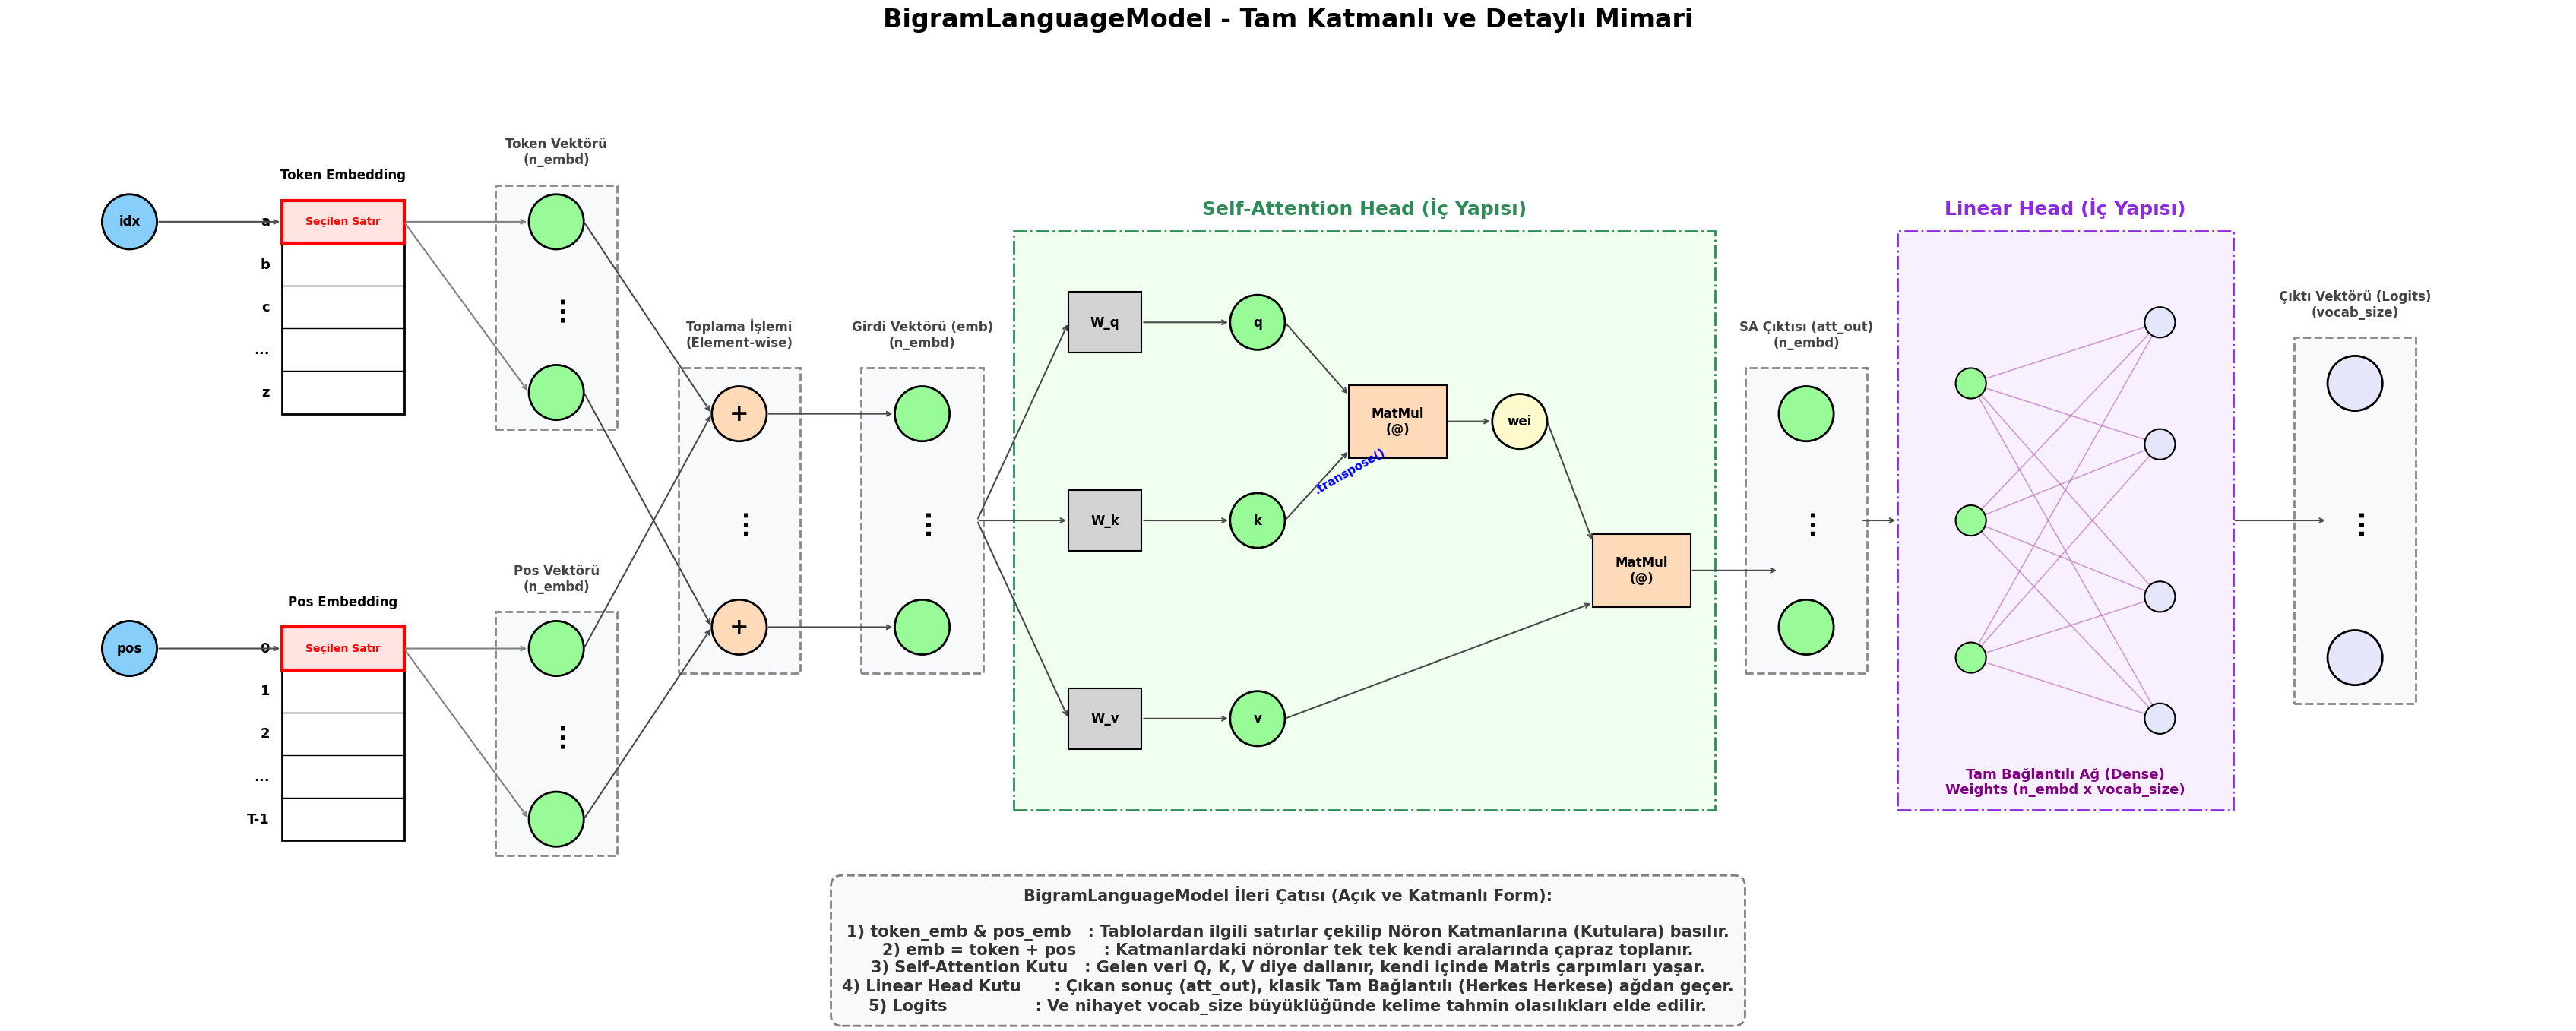

In [75]:
# görselleştirme

# Tüm Modelin En İleri Düzey (Katmanlı ve İçi Açık) Görselleştirmesi
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Her şeyi sığdırmak için devasa, ultra-geniş bir çizim alanı
fig, ax = plt.subplots(figsize=(34, 14))
ax.set_title("BigramLanguageModel - Tam Katmanlı ve Detaylı Mimari", fontsize=24, fontweight='bold', pad=20)
ax.axis('off')

# Çizim sınırları
ax.set_xlim(0, 42)
ax.set_ylim(0, 16)
ax.set_aspect('equal')

r = 0.45
arr = dict(arrowstyle="->", color="#4a4a4a", lw=1.5)

# ================= YARDIMCI FONKSİYONLAR =================
def draw_node(ax, x, y, text, color, fontsize=12):
    ax.add_patch(patches.Circle((x, y), r, color=color, ec='black', lw=2, zorder=4))
    if text:
        ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', zorder=5)

def draw_small_node(ax, x, y, color):
    ax.add_patch(patches.Circle((x, y), 0.25, color=color, ec='black', lw=1.5, zorder=4))

def draw_box(ax, x, y, w, h, text, color):
    ax.add_patch(patches.Rectangle((x - w/2, y - h/2), w, h, ec='black', fc=color, lw=1.5, zorder=3))
    ax.text(x, y, text, ha='center', va='center', fontsize=12, fontweight='bold', zorder=5)

# Nöronların etrafını saran Katman (Layer) Kutuları
def draw_layer_box(ax, x_center, y_center, w, h, text):
    ax.add_patch(patches.Rectangle((x_center - w/2, y_center - h/2), w, h, ec='#888888', fc='#f8f9fa', lw=2, ls='--', zorder=1))
    ax.text(x_center, y_center + h/2 + 0.3, text, ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444444')

# Matris Çizici
def draw_emb_matrix(ax, x, y_bot, w, h, title, labels, hl_idx, hl_text):
    ax.add_patch(patches.Rectangle((x, y_bot), w, h, ec='black', fc='white', lw=2, zorder=2))
    n_rows = len(labels)
    row_h = h / n_rows
    for i in range(1, n_rows):
        ax.plot([x, x + w], [y_bot + i*row_h, y_bot + i*row_h], color='black', lw=1, zorder=2)
    for i, lbl in enumerate(reversed(labels)):
        ax.text(x - 0.2, y_bot + i*row_h + row_h/2, lbl, ha='right', va='center', fontsize=13, fontweight='bold')
    ax.text(x + w/2, y_bot + h + 0.3, title, ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    hy = y_bot + (n_rows - 1 - hl_idx) * row_h
    ax.add_patch(patches.Rectangle((x, hy), w, row_h, ec='red', fc='#ffe4e1', lw=3, zorder=3))
    ax.text(x + w/2, hy + row_h/2, hl_text, ha='center', va='center', fontsize=10, color='red', fontweight='bold', zorder=5)
    return hy + row_h/2

# ================= 1. GİRDİLER VE MATRİSLER =================
mat_x, mat_w, mat_h = 4.5, 2.0, 3.5

ty = draw_emb_matrix(ax, mat_x, 10.0, mat_w, mat_h, "Token Embedding", ['a', 'b', 'c', '...', 'z'], 0, "Seçilen Satır")
py = draw_emb_matrix(ax, mat_x, 3.0, mat_w, mat_h, "Pos Embedding", ['0', '1', '2', '...', 'T-1'], 0, "Seçilen Satır")

draw_node(ax, 2.0, ty, "idx", '#87CEFA')
draw_node(ax, 2.0, py, "pos", '#87CEFA')

ax.annotate('', xy=(mat_x, ty), xytext=(2.0+r, ty), arrowprops=arr)
ax.annotate('', xy=(mat_x, py), xytext=(2.0+r, py), arrowprops=arr)

# ================= 2. VEKTÖR KATMANLARI (Nöron Grupları) =================
t_y_bot, p_y_bot = 10.35, 3.35
layer_w = 2.0

# Token Katmanı Kutusu
draw_layer_box(ax, 9.0, 11.75, layer_w, 4.0, "Token Vektörü\n(n_embd)")
draw_node(ax, 9.0, ty, "", '#98FB98')
draw_node(ax, 9.0, t_y_bot, "", '#98FB98')
ax.text(9.0, 11.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# Pos Katmanı Kutusu
draw_layer_box(ax, 9.0, 4.75, layer_w, 4.0, "Pos Vektörü\n(n_embd)")
draw_node(ax, 9.0, py, "", '#98FB98')
draw_node(ax, 9.0, p_y_bot, "", '#98FB98')
ax.text(9.0, 4.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# Matristen Vektöre Oklar
ax.annotate('', xy=(9.0-r, ty), xytext=(mat_x+mat_w, ty), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(9.0-r, t_y_bot), xytext=(mat_x+mat_w, ty), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(9.0-r, py), xytext=(mat_x+mat_w, py), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(9.0-r, p_y_bot), xytext=(mat_x+mat_w, py), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

# ================= 3. TOPLAMA İŞLEMİ VEKTÖRÜ =================
# Toplama Katmanı Kutusu
draw_layer_box(ax, 12.0, 8.25, layer_w, 5.0, "Toplama İşlemi\n(Element-wise)")
draw_node(ax, 12.0, 10.0, "+", '#FFDAB9', fontsize=22)
draw_node(ax, 12.0, 6.5, "+", '#FFDAB9', fontsize=22)
ax.text(12.0, 8.25, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# Çapraz Toplama Okları (Token ve Pos Uç uca ekleniyor)
ax.annotate('', xy=(12.0-r, 10.0), xytext=(9.0+r, ty), arrowprops=arr)
ax.annotate('', xy=(12.0-r, 10.0), xytext=(9.0+r, py), arrowprops=arr)
ax.annotate('', xy=(12.0-r, 6.5), xytext=(9.0+r, t_y_bot), arrowprops=arr)
ax.annotate('', xy=(12.0-r, 6.5), xytext=(9.0+r, p_y_bot), arrowprops=arr)

# ================= 4. GİRDİ (EMB) VEKTÖRÜ =================
draw_layer_box(ax, 15.0, 8.25, layer_w, 5.0, "Girdi Vektörü (emb)\n(n_embd)")
draw_node(ax, 15.0, 10.0, "", '#98FB98')
draw_node(ax, 15.0, 6.5, "", '#98FB98')
ax.text(15.0, 8.25, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

ax.annotate('', xy=(15.0-r, 10.0), xytext=(12.0+r, 10.0), arrowprops=arr)
ax.annotate('', xy=(15.0-r, 6.5), xytext=(12.0+r, 6.5), arrowprops=arr)

# ================= 5. DETAYLI SELF-ATTENTION HEAD (Devasa Kutu) =================
# Ana SA Çerçevesi
ax.add_patch(patches.Rectangle((16.5, 3.5), 11.5, 9.5, ec='#2e8b57', fc='#f0fff0', lw=2, ls='-.', zorder=0))
ax.text(22.25, 13.2, "Self-Attention Head (İç Yapısı)", ha='center', va='bottom', fontsize=18, fontweight='bold', color='#2e8b57')

# Girdi'den Q, K, V Dallanması
ax.annotate('', xy=(17.4, 11.5), xytext=(15.9, 8.25), arrowprops=arr)
ax.annotate('', xy=(17.4, 8.25), xytext=(15.9, 8.25), arrowprops=arr)
ax.annotate('', xy=(17.4, 5.0), xytext=(15.9, 8.25), arrowprops=arr)

# Linear Q, K, V ağırlıkları
draw_box(ax, 18.0, 11.5, 1.2, 1.0, "W_q", '#D3D3D3')
draw_box(ax, 18.0, 8.25, 1.2, 1.0, "W_k", '#D3D3D3')
draw_box(ax, 18.0, 5.0, 1.2, 1.0, "W_v", '#D3D3D3')

# Q, K, V Nöronları
draw_node(ax, 20.5, 11.5, "q", '#98FB98')
draw_node(ax, 20.5, 8.25, "k", '#98FB98')
draw_node(ax, 20.5, 5.0, "v", '#98FB98')

ax.annotate('', xy=(20.5-r, 11.5), xytext=(18.6, 11.5), arrowprops=arr)
ax.annotate('', xy=(20.5-r, 8.25), xytext=(18.6, 8.25), arrowprops=arr)
ax.annotate('', xy=(20.5-r, 5.0), xytext=(18.6, 5.0), arrowprops=arr)

# 1. MatMul (Q @ K.T)
draw_box(ax, 22.8, 9.875, 1.6, 1.2, "MatMul\n(@)", '#FFDAB9')
ax.annotate('', xy=(22.0, 10.3), xytext=(20.5+r, 11.5), arrowprops=arr)
ax.annotate('', xy=(22.0, 9.4), xytext=(20.5+r, 8.25), arrowprops=arr)
ax.text(21.4, 8.7, ".transpose()", rotation=30, fontsize=11, color='blue', fontweight='bold')

# Wei (Ağırlıklar)
draw_node(ax, 24.8, 9.875, "wei", '#FFFACD')
ax.annotate('', xy=(24.8-r, 9.875), xytext=(23.6, 9.875), arrowprops=arr)

# 2. MatMul (Wei @ V)
draw_box(ax, 26.8, 7.43, 1.6, 1.2, "MatMul\n(@)", '#FFDAB9')
ax.annotate('', xy=(26.0, 7.9), xytext=(24.8+r, 9.875), arrowprops=arr)
ax.annotate('', xy=(26.0, 6.9), xytext=(20.5+r, 5.0), arrowprops=arr)

# ================= 6. SA ÇIKIŞI (att_out) =================
draw_layer_box(ax, 29.5, 8.25, layer_w, 5.0, "SA Çıktısı (att_out)\n(n_embd)")
draw_node(ax, 29.5, 10.0, "", '#98FB98')
draw_node(ax, 29.5, 6.5, "", '#98FB98')
ax.text(29.5, 8.25, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# SA Kutusundan çıkış
ax.annotate('', xy=(29.5-r, 7.43), xytext=(27.6, 7.43), arrowprops=arr)

# ================= 7. DETAYLI LINEAR HEAD (Devasa Kutu) =================
# Ana Linear Çerçevesi
ax.add_patch(patches.Rectangle((31.0, 3.5), 5.5, 9.5, ec='#8a2be2', fc='#f8f0ff', lw=2, ls='-.', zorder=0))
ax.text(33.75, 13.2, "Linear Head (İç Yapısı)", ha='center', va='bottom', fontsize=18, fontweight='bold', color='#8a2be2')

# att_out'tan Linear'e giriş
ax.annotate('', xy=(31.0, 8.25), xytext=(30.4, 8.25), arrowprops=arr)

# Dense (Fully Connected) Katman Çizimi
dense_in = 32.2
dense_out = 35.3
iy_list = [10.5, 8.25, 6.0]
oy_list = [11.5, 9.5, 7.0, 5.0]

# Herkesten-Herkese Bağlantı Çizgileri (Ağ Yapısı)
for iy in iy_list:
    for oy in oy_list:
        ax.plot([dense_in, dense_out], [iy, oy], color='purple', alpha=0.35, lw=1.2, zorder=2)

# Nöronlar
for iy in iy_list:
    draw_small_node(ax, dense_in, iy, '#98FB98')
for oy in oy_list:
    draw_small_node(ax, dense_out, oy, '#E6E6FA')

ax.text(33.75, 4.2, "Tam Bağlantılı Ağ (Dense)\nWeights (n_embd x vocab_size)", ha='center', va='top', fontsize=13, fontweight='bold', color='purple')

# ================= 8. LOGITS (OUTPUT) =================
draw_layer_box(ax, 38.5, 8.25, layer_w, 6.0, "Çıktı Vektörü (Logits)\n(vocab_size)")
draw_node(ax, 38.5, 10.5, "", '#E6E6FA')
draw_node(ax, 38.5, 6.0, "", '#E6E6FA')
ax.text(38.5, 8.25, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# Linear'dan Çıkış
ax.annotate('', xy=(38.5-r, 8.25), xytext=(36.5, 8.25), arrowprops=arr)

# ================= ALT KISIM BİLGİ NOTU =================
kod_metni = (
    "BigramLanguageModel İleri Çatısı (Açık ve Katmanlı Form):\n\n"
    "1) token_emb & pos_emb   : Tablolardan ilgili satırlar çekilip Nöron Katmanlarına (Kutulara) basılır.\n"
    "2) emb = token + pos     : Katmanlardaki nöronlar tek tek kendi aralarında çapraz toplanır.\n"
    "3) Self-Attention Kutu   : Gelen veri Q, K, V diye dallanır, kendi içinde Matris çarpımları yaşar.\n"
    "4) Linear Head Kutu      : Çıkan sonuç (att_out), klasik Tam Bağlantılı (Herkes Herkese) ağdan geçer.\n"
    "5) Logits                : Ve nihayet vocab_size büyüklüğünde kelime tahmin olasılıkları elde edilir."
)
ax.text(21.0, 1.2, kod_metni, fontsize=15, fontweight='bold', color='#333333',
        bbox=dict(boxstyle="round,pad=0.7", fc="#f9f9f9", ec="gray", lw=2, ls='--'), ha='center', va='center')

plt.tight_layout()
plt.show()



In [ ]:
# yaptığım hatalar

# görev 1'de
    ## encode_text = "Merhaba YZ50!" demiştim
        ### 5 ve 0 sayılarını içerdiği için hata verdi
    ## data = torch.tensor(text)
        ### encode(text) demek lazımmış
        ### pytorch'ta tensor, sadece sayı kabul ediyormuş (numpy gibi)
    ## def forward() yerine def __call__ dedim
        ### pytorch un motorunu override fln ediyomuşuz galiba ondan olmazmış